<a href="https://colab.research.google.com/github/jarizmendi18-source/repositorio-gestion/blob/main/S05_GESTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bibliotecas para uso de imágenes
import cv2

# Bibliotecas para modelos de redes neuronales artificiales con keras
import tensorflow as tf
from tensorflow.keras.preprocessing import image as image_utils
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import backend, callbacks, optimizers
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
import tensorflow.keras.utils as np_utils
from sklearn.model_selection import train_test_split
import imutils

# Bibliotecas para transferencia de conocimiento
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Para otros modelos
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

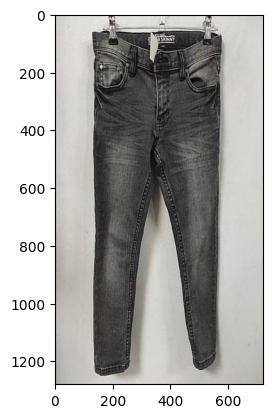

In [3]:
imagen = image_utils.load_img('/content/drive/MyDrive/S05 PRUEBA/1.jpg')
plt.imshow(imagen, cmap='Accent')
plt.show()

In [4]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [5]:
!ls -lh "/content/drive/MyDrive/s05"

total 3.7M
-rw------- 1 root root  279 Jun 14 04:20 metadata.json
-rw------- 1 root root 1.9M Jun 13 23:21 model.h5
-rw------- 1 root root  48K Jun 14 04:20 model.json
drwx------ 2 root root 4.0K Jun 13 23:42 saved_model
-rw------- 1 root root 1.8M Jun 14 04:20 weights.bin


In [6]:
!tensorflowjs_converter \
    --input_format=tfjs_layers_model \
    --output_format=keras_saved_model \
    "/content/drive/MyDrive/s05/model.json" \
    "/content/drive/MyDrive/s05/saved_model"

/bin/bash: line 1: tensorflowjs_converter: command not found


In [7]:
!ls -R "/content/drive/MyDrive/s05/saved_model"

/content/drive/MyDrive/s05/saved_model:
assets	fingerprint.pb	keras_metadata.pb  saved_model.pb  variables

/content/drive/MyDrive/s05/saved_model/assets:

/content/drive/MyDrive/s05/saved_model/variables:
variables.data-00000-of-00001  variables.index


In [8]:
import keras

layer = keras.layers.TFSMLayer(
    "/content/drive/MyDrive/s05/saved_model",
    call_endpoint="serving_default"
)

print(layer)

<TFSMLayer name=tfsm_layer, built=True>


In [9]:
import tensorflow as tf

saved_model = tf.saved_model.load(
    "/content/drive/MyDrive/s05/saved_model"
)

infer = saved_model.signatures["serving_default"]

print(infer.structured_input_signature)
print(infer.structured_outputs)

((), {'sequential_5_input': TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='sequential_5_input')})
{'sequential_7': TensorSpec(shape=(None, 3), dtype=tf.float32, name='sequential_7')}


In [19]:
import os

test_dir = "/content/drive/MyDrive/DATOS2"

print(os.listdir(test_dir))

['TRAIN']


In [21]:
import os

print(os.listdir("/content/drive/MyDrive/DATOS"))

['PANTALON', 'SUDADERA', 'PLAYERA']


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os
import numpy as np
from tensorflow.keras.preprocessing import image

# Carpetas de prueba
test_dir = "/content/drive/MyDrive/DATOS"

labels = ["PANTALON", "PLAYERA", "SUDADERA"]


y_true = []
y_pred = []

for idx, clase in enumerate(labels):

    carpeta = os.path.join(test_dir, clase)

    for archivo in os.listdir(carpeta):

        ruta = os.path.join(carpeta, archivo)

        try:
            img = image.load_img(
                ruta,
                color_mode="grayscale",
                target_size=(96,96)
            )

            img_array = image.img_to_array(img)
            img_array = img_array / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            prediction = infer(
                tf.constant(img_array, dtype=tf.float32)
            )

            probs = list(prediction.values())[0].numpy()[0]

            pred_class = np.argmax(probs)

            y_true.append(idx)
            y_pred.append(pred_class)

        except:
            print("Error en:", ruta)

In [10]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/drive/MyDrive/S05 PRUEBA/1.jpg",
    color_mode="grayscale",
    target_size=(96,96)
)

img_array = image.img_to_array(img)

# Normalización típica de Teachable Machine
img_array = img_array / 255.0

# Agregar dimensión batch
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 96, 96, 1)


In [11]:
import tensorflow as tf

saved_model = tf.saved_model.load(
    "/content/drive/MyDrive/s05/saved_model"
)

infer = saved_model.signatures["serving_default"]

prediction = infer(
    tf.constant(img_array, dtype=tf.float32)
)

print(prediction)

{'sequential_7': <tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[0.9843976 , 0.01276883, 0.00283363]], dtype=float32)>}


In [12]:
for key, value in prediction.items():
    print("Salida:", key)
    print(value.numpy())

Salida: sequential_7
[[0.9843976  0.01276883 0.00283363]]


In [13]:
labels = [
    "Pantalón",
    "Playera",
    "Sudadera"
]

In [14]:
probs = list(prediction.values())[0].numpy()[0]

clase_idx = np.argmax(probs)

print("Clase predicha:", labels[clase_idx])
print("Confianza:", f"{probs[clase_idx]*100:.2f}%")

Clase predicha: Pantalón
Confianza: 98.44%
